In [9]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class CUBDataset(Dataset):
    """
    Custom Dataset cho CUB-200-2011 lấy cả Ảnh, Label và Caption.
    Đã tối ưu cho trường hợp 1 ảnh = 1 file caption duy nhất.
    """
    def __init__(self, root_dir, text_dir=None, is_train=True, transform=None):
        self.root_dir = root_dir
        self.is_train = is_train
        self.transform = transform
        self.image_dir = os.path.join(root_dir, 'images')

        if text_dir is None:
            base_dataset_dir = os.path.dirname(root_dir) # /content/dataset_cub/
            self.text_dir = os.path.join(base_dataset_dir, 'captions')
        else:
            self.text_dir = text_dir

        images_txt = os.path.join(root_dir, 'images.txt')
        split_txt = os.path.join(root_dir, 'train_test_split.txt')
        labels_txt = os.path.join(root_dir, 'image_class_labels.txt')

        images_df = pd.read_csv(images_txt, sep=' ', names=['img_id', 'filepath'])
        split_df = pd.read_csv(split_txt, sep=' ', names=['img_id', 'is_train'])
        labels_df = pd.read_csv(labels_txt, sep=' ', names=['img_id', 'label'])

        df = images_df.merge(split_df, on='img_id').merge(labels_df, on='img_id')

        target_split = 1 if self.is_train else 0
        df = df[df['is_train'] == target_split]

        self.image_paths = df['filepath'].tolist()
        self.labels = (df['label'] - 1).tolist()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        rel_path = self.image_paths[idx]

        # image
        img_path = os.path.join(self.image_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # label
        label = self.labels[idx]

        # caption
        text_rel_path = rel_path.replace('.jpg', '.txt')
        text_path = os.path.join(self.text_dir, text_rel_path)

        caption = ""
        if os.path.exists(text_path):
            with open(text_path, 'r', encoding='utf-8') as f:
                caption = f.read().strip()

        return image, label, caption.lower()

In [4]:
from torchvision import transforms
from torch.utils.data import DataLoader

# Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Thêm chút nhiễu nhẹ chống overfit
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Transforms
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

cub_root_dir = '/kaggle/input/datasets/nmpogg/cub-caption/CUB_200_2011'


train_dataset = CUBDataset(root_dir=cub_root_dir, is_train=True, transform=train_transforms)
test_dataset = CUBDataset(root_dir=cub_root_dir, is_train=False, transform=test_transforms)


batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test:  {len(test_dataset)}")

Số lượng ảnh tập Train: 5994
Số lượng ảnh tập Test:  5794


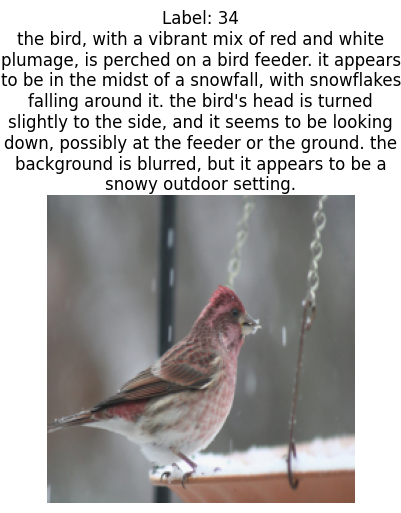

In [5]:
import matplotlib.pyplot as plt
import numpy as np

images, labels, captions = next(iter(train_loader))

img_tensor = images[0]
label_id = labels[0].item()
caption_text = captions[0]

def show_sample(img, title):
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    img = img.cpu().numpy()

    img = img.transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(title, wrap=True)
    plt.axis('off')
    plt.show()

show_sample(img_tensor, title=f"Label: {label_id}\n{caption_text}")

In [6]:
import torch
import torch.nn as nn
from transformers import ViTForImageClassification
from peft import LoraConfig, get_peft_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=200,
    ignore_mismatched_sizes=True
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    modules_to_save=["classifier"]
)

model = get_peft_model(base_model, lora_config)
model.to(device)

print("Thống kê tham số huấn luyện của ViT+LoRA:")
model.print_trainable_parameters()

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Thống kê tham số huấn luyện của ViT+LoRA:
trainable params: 743,624 || all params: 86,696,080 || trainable%: 0.8577


In [10]:
import torch
import evaluate
import numpy as np
# 1. Thêm EarlyStoppingCallback vào phần import
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

def collate_fn(batch):
    # DINOv2 expect dictionary với key 'pixel_values' và 'labels'
    images = torch.stack([x[0] for x in batch])
    labels = torch.tensor([x[1] for x in batch])
    return {"pixel_values": images, "labels": labels}

training_args = TrainingArguments(
    output_dir="./vit-cub-finetune",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-4,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True, # Bắt buộc phải là True khi dùng Early Stopping
    metric_for_best_model="accuracy", # Thêm dòng này để theo dõi accuracy (hoặc bạn có thể đổi thành "eval_loss")
    greater_is_better=True, # True nếu dùng accuracy, False nếu dùng eval_loss
    remove_unused_columns=False,
    fp16=True 
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    # 2. Truyền callback Early Stopping với patience = 3
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] 
)

print("Bắt đầu huấn luyện...")
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Bắt đầu huấn luyện...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,3.505584,0.682603
2,No log,2.089724,0.756645
3,No log,1.434721,0.806869
4,No log,1.137062,0.829134
5,No log,0.980202,0.838454
6,2.116887,0.890898,0.847946
7,2.116887,0.832932,0.849845
8,2.116887,0.798768,0.849499
9,2.116887,0.779766,0.851916
10,2.116887,0.773724,0.850708


TrainOutput(global_step=940, training_loss=1.4157551217586437, metrics={'train_runtime': 2317.0318, 'train_samples_per_second': 25.869, 'train_steps_per_second': 0.406, 'total_flos': 4.693369443375514e+18, 'train_loss': 1.4157551217586437, 'epoch': 10.0})

In [11]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

# 1. Chuyển mô hình sang chế độ đánh giá và đẩy lên GPU
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_embeddings = []
all_labels = []

print("Đang trích xuất đặc trưng (embeddings) từ tập Test...")
with torch.no_grad():
    for batch in tqdm(test_loader):
        # FIX LỖI: Tự động xử lý bất kể batch là dictionary (từ Trainer) hay list (từ DataLoader thường)
        if isinstance(batch, dict):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"]
        else:
            pixel_values = batch[0].to(device)
            labels = batch[1]
        
        # Lấy hidden states từ mô hình
        outputs = model(pixel_values, output_hidden_states=True)
        
        # Lấy đặc trưng của DINOv2 (token [CLS] ở vị trí 0)
        # Lưu ý: Nếu bạn đang dùng Swin/MaxViT, hãy đổi thành outputs.hidden_states[-1].mean(dim=1)
        embeddings = outputs.hidden_states[-1][:, 0, :]
        
        all_embeddings.append(embeddings.cpu())
        all_labels.append(labels)

# Gộp danh sách thành Tensor lớn
all_embeddings = torch.cat(all_embeddings, dim=0)
all_labels = torch.cat(all_labels, dim=0)

# Chuẩn hóa L2 các vector đặc trưng để tính Cosine Similarity dễ dàng
all_embeddings = F.normalize(all_embeddings, p=2, dim=1)

print("Đang tính toán ma trận độ tương đồng và các độ đo...")
# Tính ma trận cosine similarity kích thước (N x N)
sim_matrix = torch.mm(all_embeddings, all_embeddings.T)

# Đặt đường chéo chính bằng -inf để bỏ qua trường hợp ảnh tự truy xuất chính nó
sim_matrix.fill_diagonal_(-float('inf'))

k_values = [1, 3, 5, 7, 10, 20]
metrics = {f'Precision@{k}': [] for k in k_values}
metrics.update({f'Recall@{k}': [] for k in k_values})
metrics.update({f'MAP@{k}': [] for k in k_values})

num_samples = len(all_labels)

# Vòng lặp tính toán độ đo cho từng ảnh truy vấn (Query)
for i in range(num_samples):
    query_label = all_labels[i]
    sims = sim_matrix[i]
    
    # Sắp xếp các ảnh trong gallery theo độ tương đồng giảm dần
    sorted_indices = torch.argsort(sims, descending=True)
    gallery_labels = all_labels[sorted_indices]
    
    # Tạo mảng nhị phân: 1 nếu đúng nhãn (hit), 0 nếu sai nhãn
    hits = (gallery_labels == query_label).float()
    
    # Tổng số ảnh liên quan (cùng nhãn) trong gallery (trừ chính nó)
    total_relevant = (all_labels == query_label).sum().item() - 1 
    
    if total_relevant == 0:
        continue # Bỏ qua nếu không có ảnh nào cùng class trong tập test để truy xuất
        
    for k in k_values:
        hits_k = hits[:k]
        
        # 1. Precision@K: Tỷ lệ ảnh đúng trong K ảnh trả về đầu tiên
        precision = hits_k.sum().item() / k
        metrics[f'Precision@{k}'].append(precision)
        
        # 2. Recall@K: Tỷ lệ ảnh đúng tìm được so với tổng số ảnh đúng có trong database
        recall = hits_k.sum().item() / total_relevant
        metrics[f'Recall@{k}'].append(recall)
        
        # 3. MAP@K (Mean Average Precision): Precision trung bình có trọng số vị trí
        precisions_at_i = torch.cumsum(hits_k, dim=0) / torch.arange(1, k + 1).float()
        ap_k = (precisions_at_i * hits_k).sum().item() / min(k, total_relevant)
        metrics[f'MAP@{k}'].append(ap_k)

print("\n--- KẾT QUẢ ĐÁNH GIÁ TRUY XUẤT ẢNH (IMAGE RETRIEVAL) ---")
for k in k_values:
    p_k = np.mean(metrics[f'Precision@{k}'])
    r_k = np.mean(metrics[f'Recall@{k}'])
    map_k = np.mean(metrics[f'MAP@{k}'])
    print(f"K = {k:<2} | Precision: {p_k:.4f} | Recall: {r_k:.4f} | MAP: {map_k:.4f}")

Đang trích xuất đặc trưng (embeddings) từ tập Test...


100%|██████████| 182/182 [01:03<00:00,  2.87it/s]


Đang tính toán ma trận độ tương đồng và các độ đo...

--- KẾT QUẢ ĐÁNH GIÁ TRUY XUẤT ẢNH (IMAGE RETRIEVAL) ---
K = 1  | Precision: 0.8183 | Recall: 0.0292 | MAP: 0.8183
K = 3  | Precision: 0.8071 | Recall: 0.0863 | MAP: 0.7827
K = 5  | Precision: 0.7971 | Recall: 0.1420 | MAP: 0.7619
K = 7  | Precision: 0.7877 | Recall: 0.1963 | MAP: 0.7458
K = 10 | Precision: 0.7747 | Recall: 0.2756 | MAP: 0.7261
K = 20 | Precision: 0.7321 | Recall: 0.5191 | MAP: 0.6734
